# 1. 군집화(Clustering)  
군집화는 **비지도 학습(Unsupervised Learning)**의 일종으로, 데이터의 라벨 정보 없이 유사한 성질을 가진 데이터끼리 묶는 방법이다.

| 항목      | 설명                                         |
| ------- | ------------------------------------------ |
| 학습 방식   | 라벨이 없는 데이터를 기반으로 학습 (비지도 학습)               |
| 목적      | 유사한 데이터끼리 묶어서 그룹을 형성                       |
| 주요 알고리즘 | K-Means, DBSCAN, Hierarchical Clustering 등 |
| 활용 분야   |  고객 분류, 이미지 분석, 문서 분류 , 이상치 탐지 등            |


# 2. 군집화 알고리즘

| 알고리즘                   | 주요 개념    | 처리 과정                                                                                       | 장점                       | 단점                       |
| ---------------------- | -------- | ------------------------------------------------------------------------------------------- | ------------------------ | ------------------------ |
| **KMeans**             | 중심 기반    | ① 군집 수(K) 설정<br>② 초기 중심 선택<br>③ 샘플 할당<br>④ 중심 업데이트<br>⑤ 수렴 시 종료                             | 빠름, 대규모 데이터 적합           | 초기 중심 민감, 비선형 구조 미흡      |
| **평균 이동 (Mean Shift)** | 모드 탐색 기반 | ① 각 샘플을 중심으로 커널 밀도 계산<br>② 밀도 높은 방향으로 중심 이동<br>③ 수렴 시 모드(peak) 판단<br>④ 가까운 모드들 병합하여 군집 형성   | 군집 수 자동 결정, 복잡한 구조 탐지 가능 | 계산 비용 큼, 고차원 데이터에서 느림    |
| **GMM**                | 확률 기반    | ① 군집 수(K) 설정<br>② 초기 파라미터 설정<br>③ E-step: 소속 확률 계산<br>④ M-step: 가우시안 파라미터 업데이트<br>⑤ 수렴 시 종료 | 소속 확률 제공, 타원형 군집 탐지 가능   | 초기값 민감, 수렴 느릴 수 있음, K 필요 |
| **DBSCAN**             | 밀도 기반    | ① 반경 ε 설정 ( <- 하이퍼 파라미터) <br>② 이웃 개수 ≥ MinPts(하이퍼 파라미터) 확인<br>③ 핵심점 선정<br>④ 이웃 연결 확장<br>⑤ 잡음 구분                       | 이상치 강건, 군집 수 자동 결정 가능    | 희소데이터 부적합, 파라미터 민감       |


In [1]:
import sklearn
import platform
print(platform.system())
if platform.system()== 'Windows':
   sklearn.set_config(display='text')

Windows


In [2]:

import matplotlib.pyplot as plt

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

# 데이터 불러오기
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 정답 라벨 (평가용)

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 시각화를 위한 차원 축소 (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)


(569, 2)


### 3. DBSCAN(Density-Based Spatial Clustering of Applications with Noise) 클러스터링

밀도 기반의 비지도 학습 알고리즘으로, 데이터의 밀도를 기준으로 군집을 형성하고 **이상치(Noise)**를 구분한다.

- DBSCAN 처리 과정

| 단계                   | 설명                                          |
| -------------------- | ------------------------------------------- |
| ① 파라미터 설정            | 반경 `eps`, 최소 이웃 수 `min_samples` 지정          |
| ② 핵심점(Core point) 판단 | 해당 점 주변 `eps` 이내에 `min_samples` 이상 존재하면 핵심점 |
| ③ 밀도 확장              | 핵심점과 연결된 점들을 같은 군집으로 확장                     |
| ④ 경계점 처리             | 핵심점 주변에는 있지만 핵심은 아닌 점을 포함                   |
| ⑤ 이상치 분리             | 어느 군집에도 속하지 않은 점은 `Noise(-1)`로 분류           |


- DBSCAN 장단점

| 장점                 | 단점                          |
| ------------------ | --------------------------- |
| 군집 수 **사전 지정 불필요** | `eps`, `min_samples` 튜닝 어려움 |
| **이상치 감지** 기능 내장   | 밀도 차 큰 데이터에서 성능 저하          |
| 비구형 군집도 잘 탐지       | 고차원 데이터에선 거리 기반 한계          |



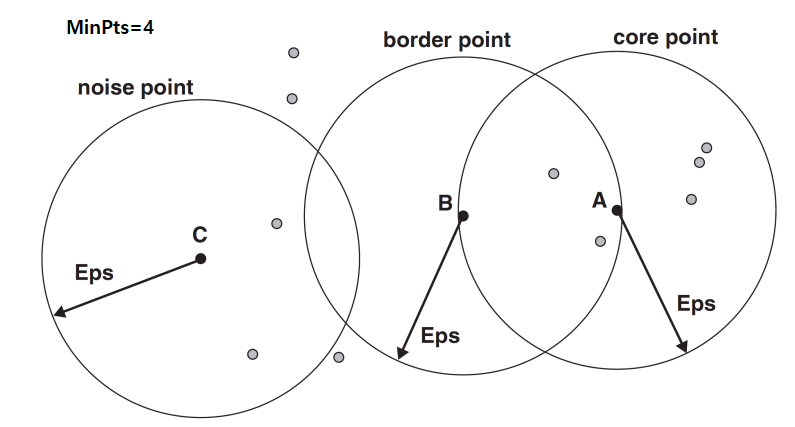

In [6]:
# DBSCAN 모델 학습
dbscan = DBSCAN(eps=2, min_samples=5)

print(f'dir(dbscan) : {dir(dbscan)}')
dbscan_labels = dbscan.fit_predict(X_scaled)

#print(f'dbscan_labels : {dbscan_labels}')

print(f'dbscan_labels : {pd.Series(dbscan_labels).value_counts() }')
print()

dbscan.fit(X_scaled)
print(dir(dbscan))
print(dbscan.labels_)



dir(dbscan) : ['__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_get_class_level_metadata_request_values', '_get_doc_link', '_get_fitted_attr_html', '_get_metadata_request', '_get_param_names', '_get_params_html', '_html_repr', '_parameter_constraints', '_repr_html_inner', '_repr_mimebundle_', '_validate_params', 'algorithm', 'eps', 'fit', 'fit_predict', 'get_metadata_routing', 'get_params', 'leaf_size', 'metric', 'metric_params', 'min_samples', 'n_jobs', 'p', 'set_fit_request', 'set_params']
dbscan_labels : -1    371
 1    181
 0 

DBSCAN 모델도 .fit() 또는 .fit_predict()를 호출한 후, 학습된 객체에서 다양한 **속성(attributes)**을 통해 결과를 확인할 수 있습니다.

다만, KMeans와는 달리 DBSCAN은 중심점 중심의 모델이 아니기 때문에, 중심 관련 속성은 존재하지 않는다. 따라서 .cluster_centers_, .inertia_ 등의 속성은 존재하지 않는다.

| 속성명                         | 설명                          | 타입                                             |활용 예|
| --------------------------- | --------------------------- | ---------------------------------------------- |--|
| **`.labels_`**              | 각 데이터 포인트의 군집 레이블 (-1은 이상치) | array, shape = (n\_samples,)                   |시각화, 군집 수 계산|
| **`.core_sample_indices_`** | 핵심점(core point)의 인덱스 리스트    | array   |핵심/경계/이상치 분석|                                       |
| **`.components_`**          | 핵심점(core samples)들의 데이터 좌표  | array, shape = (n\_core\_samples, n\_features) |시각화 또는 추출|
| **`.n_features_in_`**       | 입력 특성(feature)의 수 (v1.0 이상) | int                                            |모델 구조 확인용|
| **`.feature_names_in_`**    | 피처 이름 (입력이 DataFrame일 경우)   | array                                          |해석 시 편리|


.labels_: 각 샘플의 군집 번호

In [7]:
print(dbscan.labels_[:10])
# 예: [ 0  0  0  0 -1  1  1  1  1  1]
# → -1은 Noise (이상치)


unique, counts = np.unique(dbscan.labels_, return_counts=True)

for label, count in zip(unique, counts):
    print(f"클러스터 {label}: {count}개")


[-1 -1 -1 -1 -1 -1  0 -1 -1 -1]
클러스터 -1: 371개
클러스터 0: 12개
클러스터 1: 181개
클러스터 2: 3개
클러스터 3: 2개


.core_sample_indices_: 핵심점 인덱스


In [8]:
print(len(dbscan.core_sample_indices_))  # 핵심점의 개수
print(dbscan.core_sample_indices_[:5])


136
[ 6 40 48 49 50]


.components_: 핵심점 좌표

In [9]:
print(dbscan.components_.shape)
# → (핵심점 개수, 피처 개수)


(136, 30)


.n_features_in_ (v1.0+)

In [ ]:
print(dbscan.n_features_in_)
# → 30 (유방암 데이터셋의 특성 수)


30


.feature_names_in_ (DataFrame 사용 시)

In [10]:
import pandas as pd

X_df = pd.DataFrame(data.data, columns=data.feature_names)
X_scaled_df = pd.DataFrame(scaler.fit_transform(X_df), columns=X_df.columns)
# 위 : Z score로 스케일링 한 값

dbscan = DBSCAN(eps=1.5)
dbscan.fit(X_scaled_df)

print(dbscan.feature_names_in_[:5])
# 피쳐가 원래는 30개인데 5개만 가져옴.


['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


평가 지표

In [19]:
print(len(dbscan_labels))
print(set(dbscan_labels))
print(len(set(dbscan_labels)))

print( ( 1 if -1 in dbscan_labels else 0 ) )

print( list(dbscan_labels).count(-1) )

569
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}
5
1
371


In [ ]:
# -1은 noise (이상치)
# 클러스트 갯수 = 총 dbscan_labels 에서 중복되지 않은 값의 갯수에서 -1을 뺀 갯수
# (1을 뺀 갯수는 노이즈에 의해 결정?)
# 4

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
# 위 : set : 중복제거 => 출력값: -1,0,1,2,3     &       노이즈 값 빼오기.

# -1 값의 갯수를 리턴
n_noise = list(dbscan_labels).count(-1)

print("Estimated number of clusters:", n_clusters)      # 4개
print("Estimated number of noise points:", n_noise)     # 371개

# 평가지표
if len(set(dbscan_labels)) > 1:
    print("Silhouette Score:", silhouette_score(X_scaled, dbscan_labels))
    print("Adjusted Rand Index:", adjusted_rand_score(y, dbscan_labels))
else:
    print("군집이 하나뿐이거나 모두 Noise입니다.")


Estimated number of clusters: 4
Estimated number of noise points: 371
Silhouette Score: -0.19851389887763776
Adjusted Rand Index: 0.09635079487159537


시각화

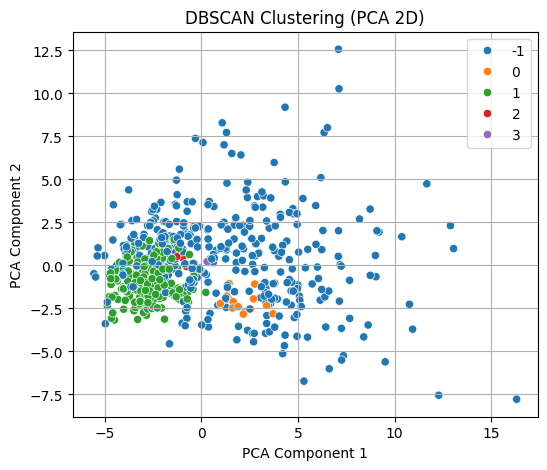

In [ ]:
plt.figure(figsize=(6,5))
palette = sns.color_palette('tab10', len(set(dbscan_labels)))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=dbscan_labels, palette=palette, legend='full')
plt.title("DBSCAN Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

전체소스

(569, 2)
DBSCAN Silhouette Score: -0.19851389887763776
DBSCAN Adjusted Rand Index: 0.09635079487159537


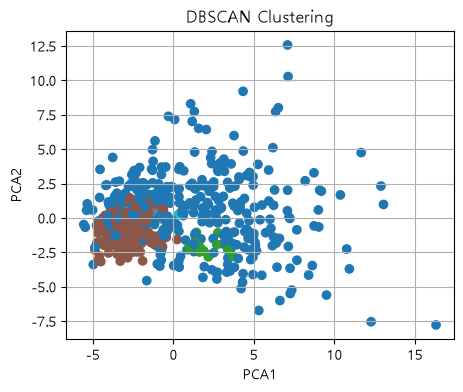

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

# 데이터 불러오기
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 정답 라벨 (평가용)

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 시각화를 위한 차원 축소 (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)



dbscan = DBSCAN(eps=2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# -1은 잡음 (Noise)
print("DBSCAN Silhouette Score:", silhouette_score(X_scaled, dbscan_labels))
print("DBSCAN Adjusted Rand Index:", adjusted_rand_score(y, dbscan_labels))

plt.figure(figsize=(5,4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10')
plt.title("DBSCAN Clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True)
plt.show()


DBSCAN 단계별 처리 요약

기본 개념

| 용어               | 의미                                    |
| ---------------- | ------------------------------------- |
| **ε (epsilon)**  | 반지름 거리. 반경 내 이웃 탐색 범위                 |
| **MinPts**       | 핵심점이 되기 위한 최소 이웃 수                    |
| **Core Point**   | ε 거리 내에 MinPts 이상 이웃이 있는 점            |
| **Border Point** | Core Point 근처에 있지만, 자체적으로는 Core가 아닌 점 |
| **Noise Point**  | Core도 아니고 Border도 아닌 점                |


① 데이터 준비

| 샘플 | 피처1 | 피처2 | 피처3 | 피처4 | 피처5 |
| -- | --- | --- | --- | --- | --- |
| x₁ | 1   | 1   | 1   | 1   | 1   |
| x₂ | 2   | 2   | 2   | 2   | 2   |
| x₃ | 8   | 8   | 8   | 8   | 8   |
| x₄ | 9   | 9   | 9   | 9   | 9   |
| x₅ | 10  | 10  | 10  | 10  | 10  |


② 파라미터 설정
- epsilon (ε): 5
- MinPts: 3 (자신 포함)

③ 유클리디안 거리 행렬 계산



|        | x₁    | x₂    | x₃    | x₄    | x₅    |
| ------ | ----- | ----- | ----- | ----- | ----- |
| **x₁** | 0     | 2.24  | 15.65 | 17.89 | 20.12 |
| **x₂** | 2.24  | 0     | 13.41 | 15.65 | 17.89 |
| **x₃** | 15.65 | 13.41 | 0     | 2.24  | 4.47  |
| **x₄** | 17.89 | 15.65 | 2.24  | 0     | 2.24  |
| **x₅** | 20.12 | 17.89 | 4.47  | 2.24  | 0     |


 ④ Core / Border / Noise 판별

 | 샘플 | ε=5 내 이웃 수 | Core 여부         | 이웃들    |
| -- | ---------- | --------------- | ------ |
| x₁ | 1 (x₁, x₂)     | x(MinPts=3 미만) | x₂     |
| x₂ | 1 (x₁, x₂)     | x               | x₁     |
| x₃ | 2 (x₃, x₄, x₅) | o               | x₄, x₅ |
| x₄ | 2 (x₃, x₄, x₅) | o               | x₃, x₅ |
| x₅ | 2 (x₃, x₄, x₅) | o               | x₃, x₄ |


⑤ 클러스터 형성 과정

- x₃가 Core → x₄, x₅로 확장
- x₄, x₅도 Core → 서로 연결 → 클러스터 1 형성
- x₁, x₂는 Core 아님 → Noise로 판단

최종 결과

| 샘플 | 역할    | 클러스터 |
| -- | ----- | ---- |
| x₁ | Noise | -1   |
| x₂ | Noise | -1   |
| x₃ | Core  | 0    |
| x₄ | Core  | 0    |
| x₅ | Core  | 0    |


 DBSCAN 단계별 요약표

 | 단계 | 내용      | 결과 요약                                |
| -- | ------- | ------------------------------------ |
| ①  | 데이터 구성  | x₁\~x₅ (5차원)                         |
| ②  | 파라미터 설정 | ε=5, MinPts=3                        |
| ③  | 거리 계산   | 거리 행렬 계산                             |
| ④  | Core 판별 | x₃, x₄, x₅는 Core / x₁, x₂는 Noise     |
| ⑤  | 클러스터 생성 | x₃, x₄, x₅ → 클러스터 0 / x₁, x₂ → Noise |


In [24]:
import numpy as np
import pandas as pd

# 1. 데이터 및 파라미터 정의
X = np.array([
    [1, 1, 1, 1, 1],   # x1
    [2, 2, 2, 2, 2],   # x2
    [8, 8, 8, 8, 8],   # x3
    [9, 9, 9, 9, 9],   # x4
    [10, 10, 10, 10, 10] # x5
])

eps = 5
min_pts = 3
sample_names = [f"x{i+1}" for i in range(len(X))]

# 2. 유클리드 거리 행렬 계산
dist_matrix = np.linalg.norm(X[:, np.newaxis] - X[np.newaxis, :], axis=2)

# 3. 조건 판정 및 결과 데이터 정리 (자기 자신 포함)
rows = []
for i in range(len(X)):
    # 자기 자신을 포함하여 반경(eps) 내 이웃 추출
    neighbors = [sample_names[j] for j in range(len(X)) if dist_matrix[i][j] <= eps]
    
    neighbors_str = ", ".join(neighbors)
    eps_count_str = f"{len(neighbors)} ({neighbors_str})"
    
    # 코어 포인트 조건: 자기 자신 포함 이웃 수 >= MinPts
    if len(neighbors) >= min_pts:
        core_status = "O"
    else:
        core_status = 'X'
        #core_status = f"X (MinPts={min_pts} 미만)" if i == 0 else "X"
        
    rows.append({
        "샘플": sample_names[i],
        "ε=5 내 이웃 수": eps_count_str,
        "Core 여부": core_status,
        #"이웃들": neighbors_str
    })

# 4. DataFrame 생성 및 출력
df_result = pd.DataFrame(rows)
print(df_result.to_string(index=False))

샘플     ε=5 내 이웃 수 Core 여부
x1     2 (x1, x2)       X
x2     2 (x1, x2)       X
x3 3 (x3, x4, x5)       O
x4 3 (x3, x4, x5)       O
x5 3 (x3, x4, x5)       O


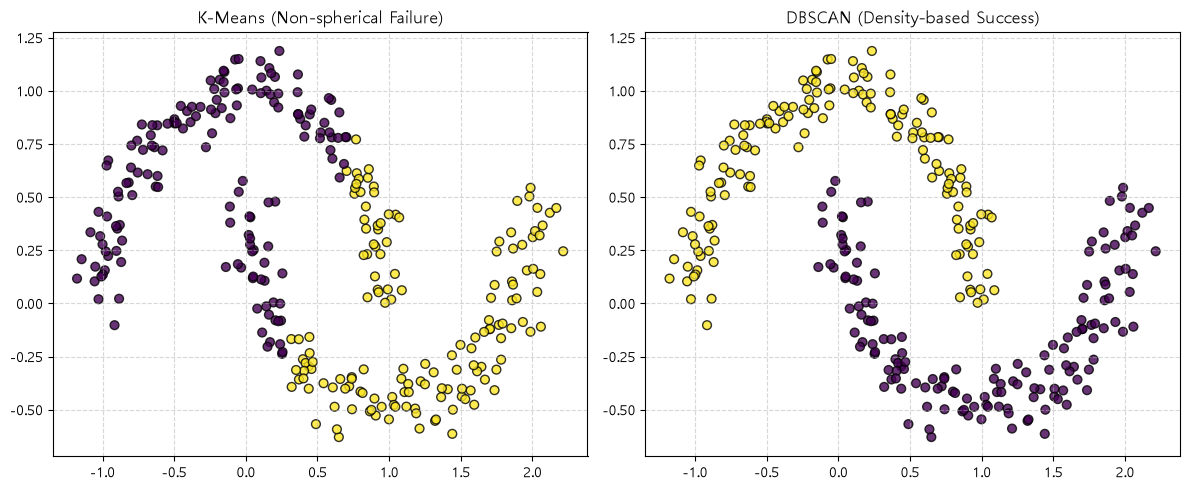

--- DBSCAN 군집화 요약 ---
추출된 군집 개수 : 2개
감지된 이상치(노이즈) 개수 : 0개


In [25]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons

# 1. 초승달 모양 데이터셋 생성 (노이즈 추가)
X, y = make_moons(n_samples=300, noise=0.08, random_state=42)

# 2. DBSCAN 및 K-Means 모델 생성 및 학습
# DBSCAN: 반경(eps)=0.2, 최소 이웃 수(min_samples)=5
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# 비교용 K-Means (K=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# 3. 시각화 (K-Means vs DBSCAN)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (1) K-Means 군집화 결과
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=40,
    edgecolors="k",
    alpha=0.8,
)
axes[0].set_title("K-Means (Non-spherical Failure)", fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.5)

# (2) DBSCAN 군집화 결과
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=dbscan_labels,
    cmap="viridis",
    s=40,
    edgecolors="k",
    alpha=0.8,
)
axes[1].set_title("DBSCAN (Density-based Success)", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 4. DBSCAN 결과 출력
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"--- DBSCAN 군집화 요약 ---")
print(f"추출된 군집 개수 : {n_clusters}개")
print(f"감지된 이상치(노이즈) 개수 : {n_noise}개")